# Part 1: Dogs vs Cats Under Tile Orders
This notebook trains three image-classification architecture families on Dogs vs Cats.
It evaluates how fixed tile-wise tile permutations affect validation accuracy.
Results are aggregated by tile count and plotted as accuracy vs number of tiles.


## Setup

### Global / External Imports
Import third-party libraries used only for notebook orchestration and display.


most basic imports

In [1]:
import sys
import os
from pathlib import Path

### Local Imports
Import project modules. Part 1 orchestration lives in this notebook; reusable training, preprocessing, and evaluation helpers stay in `src`.


prep for local imports

In [2]:
def get_project_root() -> str:
    """Resolve the project root in local notebooks, Drive-backed Colab, or cloned Colab runs."""
    try:
        from google.colab import drive  # type: ignore

        drive.mount('/content/drive')
        drive_root = Path('/content/drive/MyDrive/MLDS_Final_Project')
        if drive_root.exists():
            return str(drive_root)
    except ImportError:
        pass
    except Exception as exc:
        print(f'Google Drive was not mounted automatically: {exc}')

    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'requirements.txt').exists():
            return str(candidate)
    return str(current)

def install_project_requirements_for_colab(project_root: Path) -> None:
    """Install non-PyTorch dependencies in Colab without replacing CUDA-matched torch wheels."""
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return

    import subprocess

    requirements_path = project_root / 'requirements.txt'
    filtered_requirements = Path('/tmp/mlds_colab_requirements.txt')
    skip_prefixes = ('torch', 'torchvision')
    filtered_lines = [
        line
        for line in requirements_path.read_text().splitlines()
        if not line.strip().lower().startswith(skip_prefixes)
    ]
    filtered_requirements.write_text('\n'.join(filtered_lines) + '\n')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(filtered_requirements)])

# Add project root to sys.path so we can import modules from src
REPO_PATH = get_project_root()
if str(REPO_PATH) not in sys.path:
    sys.path.insert(0, str(REPO_PATH))

os.chdir(REPO_PATH)
install_project_requirements_for_colab(Path(REPO_PATH))
print(f"Project root: {REPO_PATH}")


Project root: /Users/royrubin/Documents/GitHub/MLDS_Final_Project


make local imports

In [3]:
import importlib
import src.utils.config as config_module
import src.models.factory as model_factory
import src.evaluation.experiment_results as experiment_results
import src.experiments.part1 as part1_experiments

config_module = importlib.reload(config_module)
model_factory = importlib.reload(model_factory)
experiment_results = importlib.reload(experiment_results)
part1_experiments = importlib.reload(part1_experiments)

CVExperimentConfig = config_module.CVExperimentConfig
experiment_output_paths = experiment_results.experiment_output_paths
get_device = experiment_results.get_device
load_experiment_samples = experiment_results.load_experiment_samples
plot_accuracy_vs_tiles = experiment_results.plot_accuracy_vs_tiles
save_aggregated_accuracy = experiment_results.save_aggregated_accuracy
save_rows = experiment_results.save_rows
train_model_on_tile_permutation_records = part1_experiments.train_model_on_tile_permutation_records
from src.preprocessing.samples import class_counts  # noqa: E402
from src.preprocessing.tile_permutations import build_tile_permutation_records, tile_permutation_to_jsonable  # noqa: E402
from src.utils.io import save_csv  # noqa: E402
from src.utils.plotting import plot_tile_permutation_samples  # noqa: E402
from src.utils.reproducibility import seed_everything  # noqa: E402

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup configs

In [4]:
configs = CVExperimentConfig()
display(configs)

CVExperimentConfig(part='part1', config_name='part1', device='auto', deterministic=False, root_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project', data_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/data/dogs-vs-cats/train', outputs_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs', results_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results', figures_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures', sample_data=True, sample_limit=256, val_fraction=0.2, test_fraction=0.0, image_size=224, batch_size=16, num_workers=2, num_classes=2, model_names=['resnet18'], pretrained=True, tiles_per_side_values=[1, 3], num_tile_permutations=2, epochs=1, learning_rate=0.0003, optimizer='adamw', weight_decay=0.0001, use_amp=False, seed=42, max_threads=4, using_google_colab=False, plot_samples=True)

Local runs use a balanced 256-image subset and 5 training epochs. With `val_fraction=0.2`, the validation split is large enough for accuracy to move in smaller steps than the old 6-image smoke-test split. In aggregated results, `final_epoch` means the metric from the last epoch, and `best_epoch` means the best validation score observed during training.

### make installations before final external imports

In [5]:
# Dependencies are installed during the setup/bootstrap cell above when running in Colab.
print('Dependency setup is complete.')


Dependency setup is complete.


### final imports (after doing pip install if working on colab)

In [6]:
import json
import random
from IPython.core.display import Image
from IPython.display import display
import pandas as pd
import numpy as np
import torch


## Experiments

### Experiment helpers
Shared helpers are kept in `src/evaluation/experiment_results.py`; notebook-specific helpers stay here.

In [7]:
def get_part1_output_paths(*, config: CVExperimentConfig) -> dict[str, str]:
    """Build stable Part 1 output paths for notebook display."""
    paths = experiment_output_paths(
        results_dir=config.results_dir,
        figures_dir=config.figures_dir,
        part_name='part1',
    )
    paths['accuracy_plot'] = paths['figure']
    return paths

### Setup Exp

In [8]:
# 4. Reproducibility (important for multiple notebooks
random.seed(configs.seed)
np.random.seed(configs.seed)
torch.manual_seed(configs.seed)
torch.set_num_threads(configs.max_threads)  # avoid contention across notebooks

In [9]:
output_paths = get_part1_output_paths(config=configs)
output_paths

{'raw_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_raw_results.csv',
 'aggregated_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_aggregated_results.csv',
 'figure': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png',
 'tile_permutations': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_tile_permutations.csv',
 'accuracy_plot': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png'}

### Data Loading
Discover the configured Dogs vs Cats split before training.


In [10]:
train_samples, validation_samples, test_samples = load_experiment_samples(config=configs, seed=configs.seed)
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(validation_samples)}')
print(f'Test samples: {len(test_samples)}')
print('Train class counts:', class_counts(samples=train_samples))
print('Validation class counts:', class_counts(samples=validation_samples))
print('Test class counts:', class_counts(samples=test_samples))

Train samples: 204
Validation samples: 52
Test samples: 0
Train class counts: {'cat': 102, 'dog': 102}
Validation class counts: {'cat': 26, 'dog': 26}
Test class counts: {'cat': 0, 'dog': 0}


### Experiments - Run Baselines
Run the configured baseline grid/model/tile permutation sweep. Re-run this cell to regenerate Part 1 outputs.


Saved 3 tile permutation records


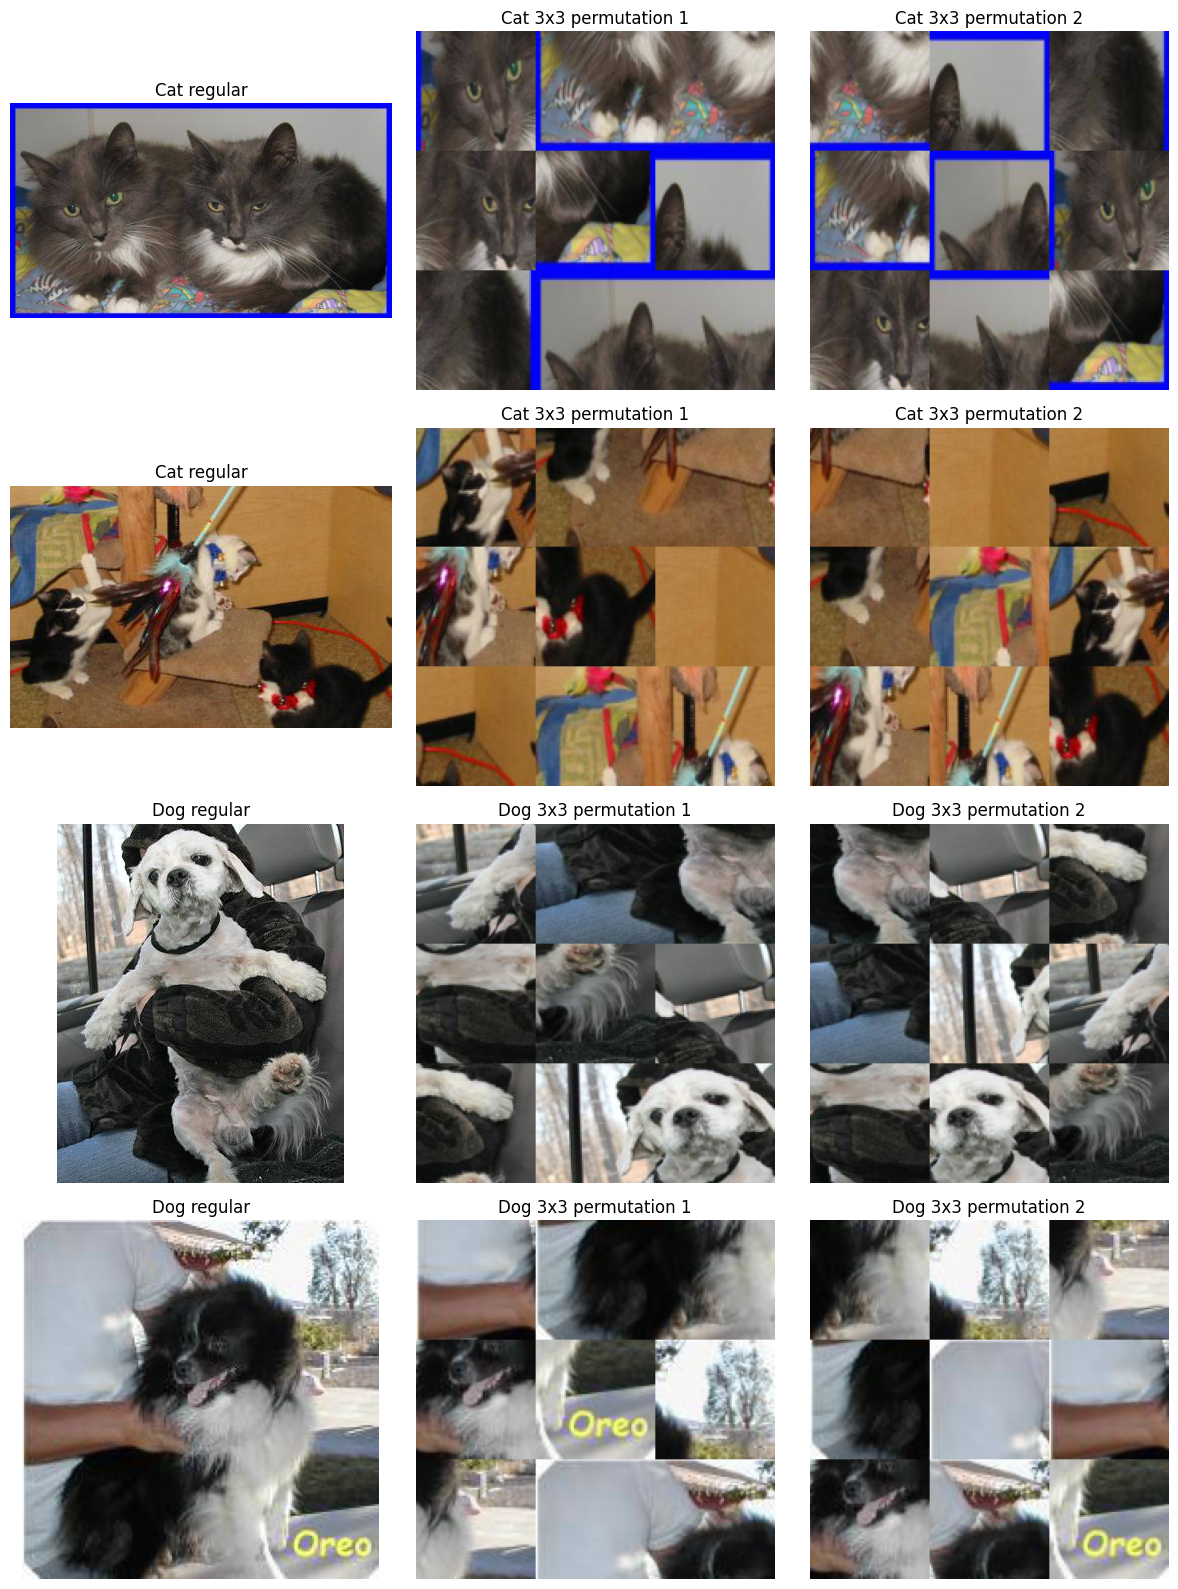

In [11]:
# Build and save tile permutation records
tile_permutation_records = build_tile_permutation_records(
    tiles_per_side_values=configs.tiles_per_side_values,
    num_tile_permutations=configs.num_tile_permutations,
    seed=configs.seed,
    include_baseline=True,
)
tile_permutation_rows = [record.__dict__ | {'tile_permutation': json.dumps(tile_permutation_to_jsonable(record.tile_permutation))} for record in tile_permutation_records]
save_csv(data=tile_permutation_rows, path=output_paths['tile_permutations'])
print(f"Saved {len(tile_permutation_records)} tile permutation records")

if configs.plot_samples:
    import matplotlib.pyplot as plt

    plot_tile_permutation_samples(
        samples=train_samples,
        tile_permutation_records=tile_permutation_records,
        image_size=configs.image_size,
    )
    plt.show()


In [12]:
# Setup reproducibility and load data
seed = configs.seed
seed_everything(seed=seed, deterministic=configs.deterministic)
# Data already loaded above
print(f"Loaded {len(train_samples)} train, {len(validation_samples)} val samples")

Loaded 204 train, 52 val samples


In [13]:
# Prepare shared result accumulation across model runs
all_rows = []
run_id = configs.config_name

### Train Lightweight Model Trio
Train the configured pretrained trio: ResNet-18, DeiT-Tiny, and MLP-Mixer Small.

In [14]:
for model_name in configs.model_names:
    device = get_device(config=configs)
    rows = train_model_on_tile_permutation_records(
        config=configs,
        model_name=model_name,
        run_id=run_id,
        train_samples=train_samples,
        validation_samples=validation_samples,
        tile_permutation_records=tile_permutation_records,
        seed=seed,
        device=device,
        raw_results_output_path=output_paths["raw_results"],
    )
    all_rows.extend(rows)
    print("Completed training", model_name, "with", len(rows), "runs")

Selected device: cpu
Saved 3 pending row(s) for model 'resnet18'.

[1/3] model=resnet18, tiles_per_side=None, tile_permutation_id=0, seed=42, stages=1 [standard: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Building model 'resnet18'...


resnet18 1x1 permutation 0: 100%|██████████| 1/1 [01:24<00:00, 84.28s/epoch, best_val_accuracy=0.865, stage=standard, train_accuracy=0.833, train_loss=0.308, val_accuracy=0.865, val_loss=0.376]


Current run runtime: 1m 25s
Total training runtime: 1m 25s

[2/3] model=resnet18, tiles_per_side=3, tile_permutation_id=1, seed=42, stages=1 [standard: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Building model 'resnet18'...


resnet18 3x3 permutation 1: 100%|██████████| 1/1 [01:31<00:00, 91.62s/epoch, best_val_accuracy=0.885, stage=standard, train_accuracy=0.809, train_loss=0.412, val_accuracy=0.885, val_loss=0.273]


Current run runtime: 1m 32s
Total training runtime: 3m 18s

[3/3] model=resnet18, tiles_per_side=3, tile_permutation_id=2, seed=42, stages=1 [standard: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Building model 'resnet18'...


resnet18 3x3 permutation 2: 100%|██████████| 1/1 [01:33<00:00, 93.17s/epoch, best_val_accuracy=0.788, stage=standard, train_accuracy=0.799, train_loss=0.404, val_accuracy=0.788, val_loss=0.6]


Current run runtime: 1m 34s
Total training runtime: 5m 11s
Completed training resnet18 with 3 runs


In [15]:
# Aggregate results and plot
raw_results = pd.read_csv(filepath_or_buffer=output_paths['raw_results'])
aggregated_results = save_aggregated_accuracy(
    raw_results=raw_results,
    group_columns=['model_name', 'tiles_per_side', 'num_tiles'],
    output_path=output_paths['aggregated_results'],
)
plot_accuracy_vs_tiles(aggregated=aggregated_results, output_path=output_paths['accuracy_plot'])
aggregated_results

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,3.0,9,0.836538,0.067991,0.836538,0.067991,2
1,resnet18,NaN,1,0.865385,NaN,0.865385,NaN,1


### Experiments - Results Table
Reload the saved aggregated CSV so the report is reproducible from disk. Each row averages all tile permutation scores for the same model and tile count.


In [16]:
saved_results = {
    'raw': pd.read_csv(filepath_or_buffer=output_paths['raw_results']),
    'aggregated': pd.read_csv(filepath_or_buffer=output_paths['aggregated_results']),
}
display(saved_results['aggregated'])

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,3.0,9,0.836538,0.067991,0.836538,0.067991,2
1,resnet18,NaN,1,0.865385,NaN,0.865385,NaN,1


### Experiments - Accuracy Plot
Display the saved accuracy-vs-number-of-tiles plot.


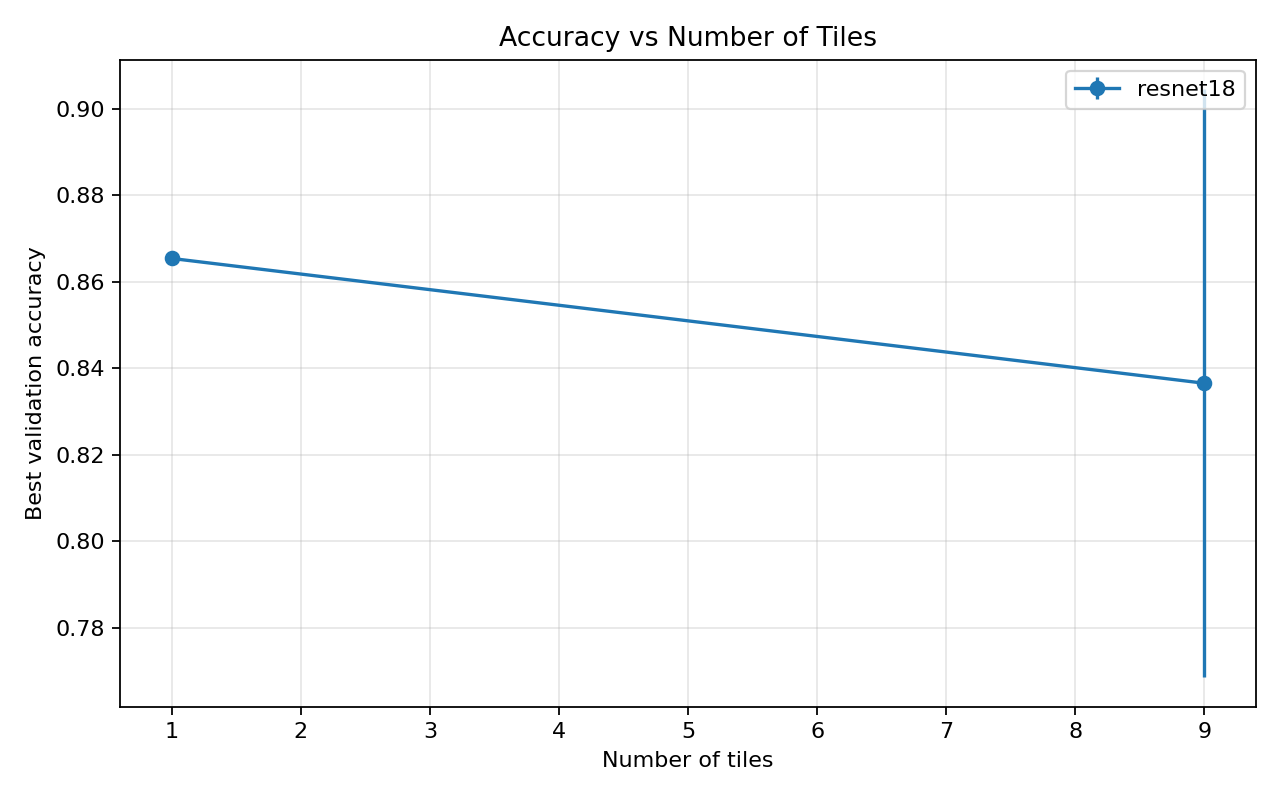

In [17]:
figure_path = output_paths['accuracy_plot']
if Path(figure_path).exists():
    display(Image(filename=figure_path))
else:
    print(f'Plot not found yet: {figure_path}')
